<a href="https://colab.research.google.com/github/u9828057/Python_Practice/blob/main/Electronics_with_Python/Electronics_Simulation_Day26_08_19_MOSFET_%E6%B1%B2%E6%A5%B5%E7%89%B9%E6%80%A7%E6%9B%B2%E7%B7%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#=========================================
# --- Colab 畫圖中文顯示起手式 ---
#=========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 下載微軟正黑體 (或是 Noto 繁體中文)
!wget -q -O NotoSansTC-Regular.otf \
https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont('NotoSansTC-Regular.otf')
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False
# --------------------------------

print("環境設定完成！可以開始畫圖了！")

環境設定完成！可以開始畫圖了！


--------(Electronics_Simulation: MOSFET 汲極特性曲線)--------



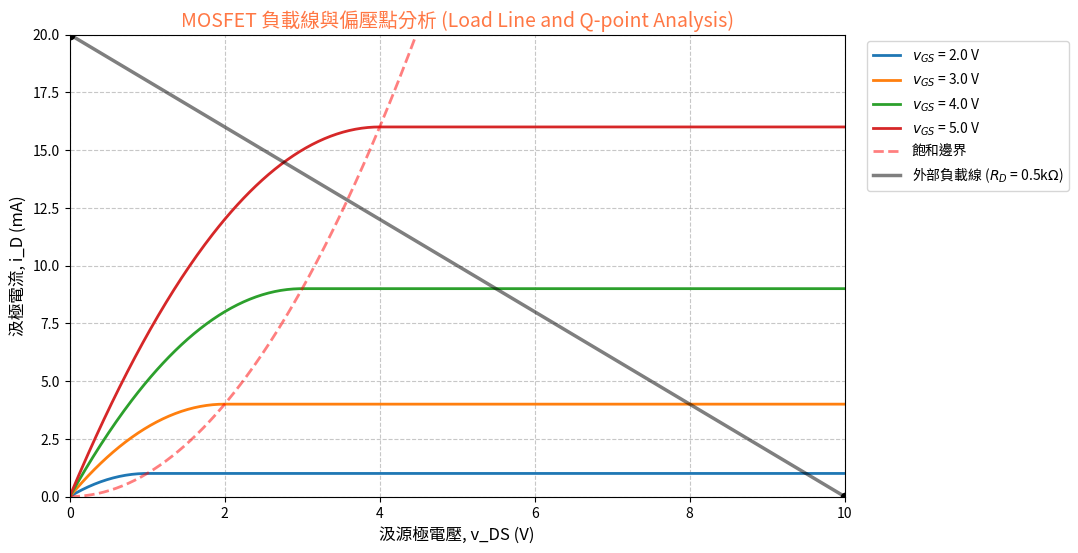

In [3]:
import numpy as np
import matplotlib.pyplot as plt
print("--------(Electronics_Simulation: MOSFET 汲極特性曲線)--------\n")

# 4.3.3. 輸入輸出電壓特性 Input-output voltage characteristics


#========================
# ◇1. 設定元件參數
#========================
V_T = 1.0  # 臨界電壓 (Threshold Voltage) (V)
K = 2e-3   # 導電參數 (A/V**2)，也就是 2mA/V**2


#=======================================
# ◇2. 建立 X 軸電壓陣列 (v_DS)
#=======================================
# 產生從 0V 到 10V 的連續陣列，共 500 個量測點
v_DS = np.linspace(0, 10.0, 500)


#======================================================
# ◇3. 迴圈繪製多條特性曲線 (Family of Curves)
#======================================================

# 觀察當 v_GS 分別為 2V, 3V, 4V, 5V 時的曲線變化
v_GS_list = [2.0, 3.0, 4.0, 5.0]

# 先在迴圈外建立一張 10x6 的畫布，這樣所有的線才會畫在同一張圖上
plt.figure(figsize=(10, 6))

for v_GS in v_GS_list:
  v_ov = v_GS - V_T  #計算過驅電壓 (Overdrive Voltage)

  #------------------------------------
  #補充技巧: np.where(條件， 成立時的值， 不成立的值)
  #------------------------------------
  # 這裡重現了數學上的「分段函數」
  # 電腦會自動檢查陣列中的每一個 v_DS:
  # 如果 v_DS < Vov (v_GS - V_T)，就帶入三極管區公式；否則就帶入飽和區公式
  i_D = np.where(
      v_DS < (v_GS - V_T),
      K*(v_ov*v_DS - 0.5*(v_DS**2)),  # 三極管區 (Triode)
      K*0.5*(v_ov**2)           # 飽和區 (Saturation)
  )

  # 繪製單條曲線 (將電流乘上 1000 轉換為 mA 單位，圖表數字會更簡潔)
  plt.plot(v_DS, i_D*1000, label=f'$v_{{GS}}$ = {v_GS} V', linewidth=2)


#==========================================================
# ◇4. 尋找並繪製工作區邊界線 (Saturation Boundary)
#==========================================================

# 邊界發生在夾止 (Pinch off): v_DS = v_GS - V_T 的瞬間
# 將這個條件帶入飽和區電流公式，可得到邊界曲線方程式為: i_D = K*0.5*(v_DS**2)
i_D_boundary = K * 0.5 * (v_DS)**2

# §補充資料：【為什麼這裡是用 v_DS**2 而不是一般常用的 (v_GS - V_T)**2 ？】
# 1. 數學條件：三極區與飽和區的交界，發生在 v_DS = (v_GS - V_T) 的瞬間
# 2. 繪圖需求：因為這張圖表的 X 軸是連續變數 v_DS (包含 500 個刻度)
#    - 如果用 0.5 * K * (v_GS - V_T)**2，只能算出那 4 條曲線轉折的「4 個獨立點」
#    - 將條件代入替換成 0.5 * K * (v_DS**2)，電腦才能順著 X 軸，
#      畫出一條貫穿整張圖表的「連續拋物線軌跡」

# 劃出這條紅色的邊界拋物線
plt.plot(v_DS, i_D_boundary*1000, "r--",
         label="飽和邊界", linewidth=2, alpha=0.5
    )


#-------------------------------------------
# ◇疊加外部 KVL 負載線 (Load Line)
#-------------------------------------------
V_DD = 10.0  # 汲極電壓電源 (V)
R_D = 5e2   # 汲極電阻 (Ohm)

# 根據直線方程式計算對應的電流陣列
# 為了配合圖表的 mA 單位，最後必須乘上 1000
i_D_loadline = ((V_DD - v_DS)/R_D) * 1000

# 繪製負載線 (使用黑色粗實線)
plt.plot(v_DS, i_D_loadline,
    color="black", linestyle="-", linewidth=2.5, alpha=0.5,
    label=rf"外部負載線 ($R_D$ = {R_D/1000:.1f}k$\Omega$)"
    )

# 視覺化小技巧: 標示 X 軸與 Y 軸的截距點
plt.plot(V_DD, 0, "ko", markersize=6)        # X 軸截距
plt.plot(0, (V_DD/R_D)*1000, "ko", markersize=6)  # Y 軸截距


#==============================
# ◇5. 數據視覺化格式設定
#==============================

plt.title("MOSFET 負載線與偏壓點分析 (Load Line and Q-point Analysis)",
          fontsize=14, fontweight="bold",
          color="#FF7744"
    )
plt.xlabel("汲源極電壓, v_DS (V)", fontsize=12)
plt.ylabel("汲極電流, i_D (mA)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1))

# 限制坐標軸顯示範圍
plt.xlim(0, 10)
plt.ylim(0, 20)

# 將畫好的圖存成高畫質 PNG 檔，並顯示圖片
plt.savefig("MOSFET 負載線與偏壓點分析.png", dpi=300, bbox_inches="tight")
plt.show()

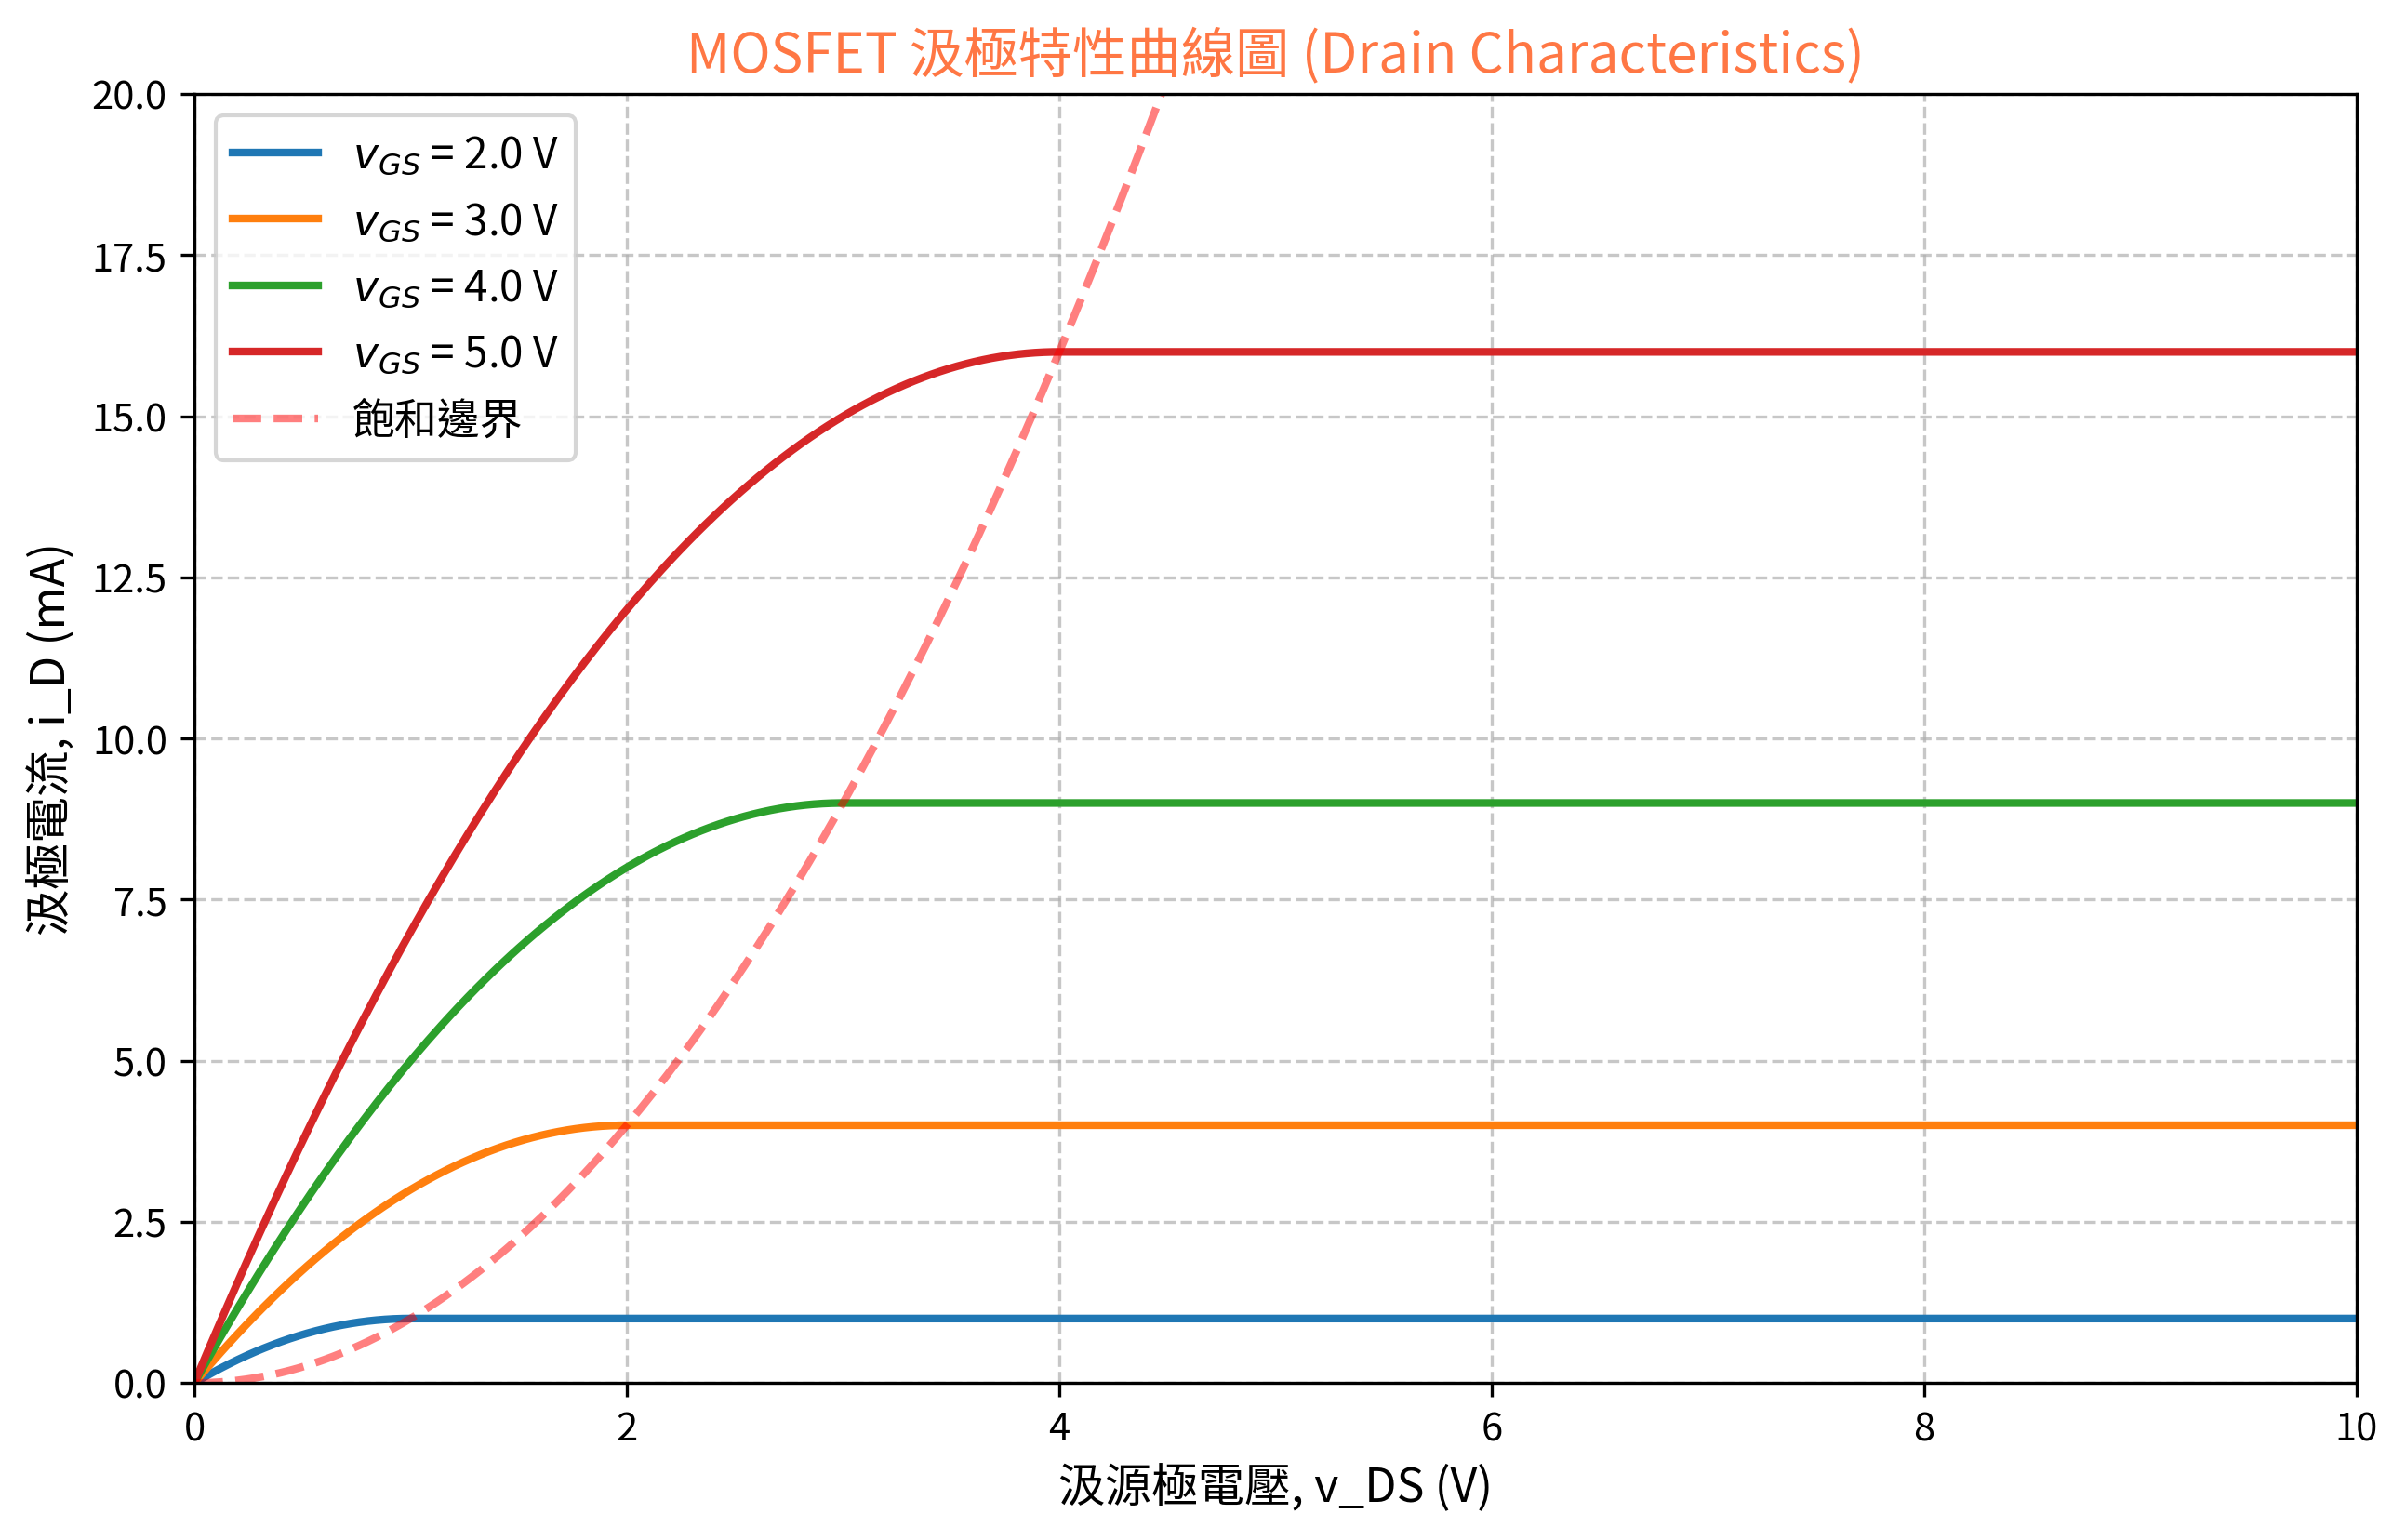

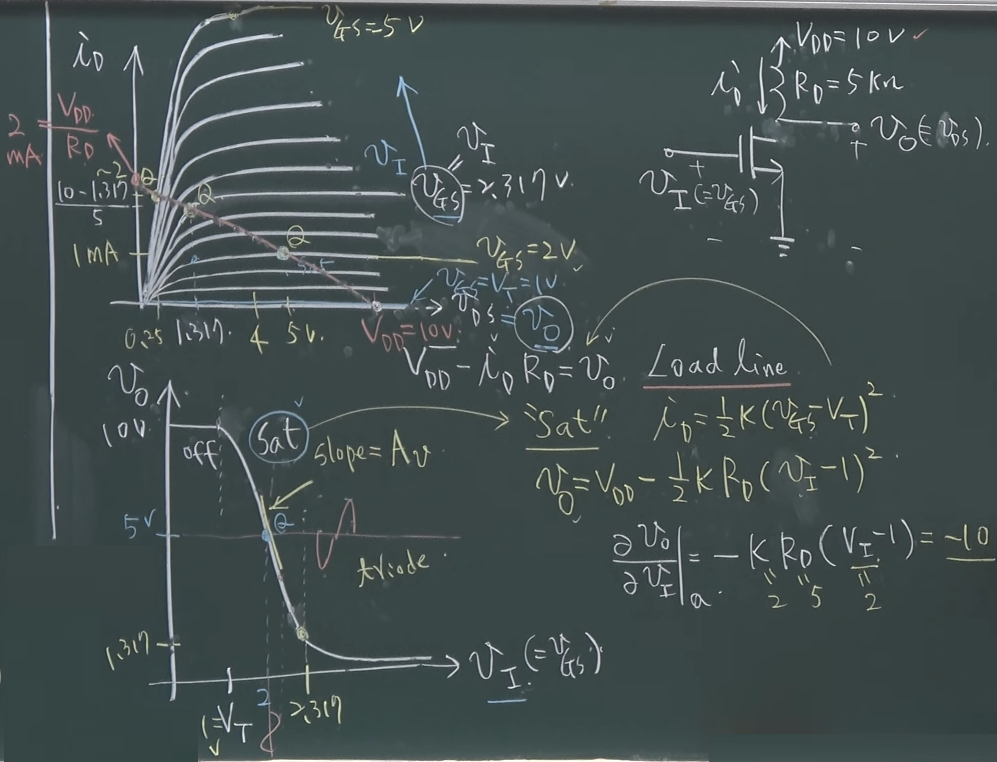

In [ ]:
#================================================================
# §理想 MOSFET 模型的汲極電流 i_D 在不同工作區的方程式
#================================================================

# 電晶體已經開啟 (v_GS > V_T):

# 歐姆區 (Deep Triode Region/Ohmic Region): 當 v_DS << v_GS -V_T 時
# i_D = K*[(v_GS - V_T)v_DS]

# 三極管區 (Triode Region): 當 v_DS < v_GS - V_T 時
# i_D = K*[(v_GS - V_T)*v_DS - 0.5*(v_DS**2)]

# 飽和區 (Saturation Region): 當 v_DS >= v_GS - V_T 時
# i_D = K*0.5[(v_GS - V_T)**2]

#-------------------------------------------------------------

# 電晶體尚未開啟 (v_GS <= V_T):

# 截止區 (Cutoff Region): 當 v_GS <= V_T 時
# i_D = 0


#===========================
# 外部電路限制: 負載線
#===========================

# 在外部電路中，根據 KVL 電壓電源會分配給汲極電阻與 MOSFET 兩端: V_DD - (i_D * R_D) = v_DS
# 為了將這條線畫在以 "v_DS" 為 X 軸、"i_D" 為 Y 軸的圖表上，
# 可以將公式移項: i_D = -(1/R_D)*v_DS + V_DD/R_D

# 這是一條斜率為負值的直線，它的 X 軸截距發生在電流為 0 mA 時（也就是 V_DD），
# 而 Y 軸截距發生在電壓為 0V 時（也就是最大短路電流 V_DD / R_D）。


In [ ]:
# §補充技巧: Matplotlib 進階繪圖與字串格式化

#----------------------------------------------
# 1. 雙大括號 {{}} 的跳脫技巧 (Escape)
#----------------------------------------------
# [用途]: 在 f-string 中顯示 「真實的 {} 符號」，避免 Python 誤認為變數
# [場景]: 當需要在 f-string 中混用 LaTeX 數學符號時 (例如: 數學下標)
# [說明]: Python 的 f-string 看到單一 {} 會去找變數，打兩次 {{GS}}，
#      Python 會知道這是純文字且印出 {GS} 交給 Matplotlib 解析成下標

# [範例]: f"$v_{{GS}}$ = {v_GS} V"

#-------------------------------------------------
# 2. 字串最前面的 r (Raw String 原始字串)
#-------------------------------------------------
# [用途]: 關閉 Python 的「跳脫字元 (\)」翻譯功能，保留字串原貌
# [場景]: 圖表標籤需要用到含有反斜線 (\) 的 LaTeX 語法時 (例如: 希臘字母Ω $\Omega$)
# [說明]: 若不加上 r，Python 會以為 \O 像是 \n (換行) 一樣的特殊指令而報錯
#      加上 r，Python 會把 \Omega 原汁原味交給畫圖引擎畫出 Ω 符號

# [範例]: label=rf"外部負載線 ($R_D$ = 5k$\Omega$)"

#--------------------------------------------------------
# 3. "ko"， "go" 等格式字串縮寫 (Format String)
#--------------------------------------------------------
# [用途]: 在 plt.plot() 中，用最短的代碼同時設定「顏色」與「形狀」
# [參數解析]:
#   - 第一個字母是顏色: "k" 代表黑色 (blacK，因為 b 已經被藍色 Blue 用掉了)
#              "g" 代表綠色 (Green)，"r" 代表紅色 (Red)
#   - 第二個字母是形狀: "o" 代表圓形實心點，"--" 代表虛線，"-" 代表實線

# [範例]: plt.plot(X_point, Y_point, "ko")  # 畫出黑色的圓點

#-----------------------------------------------
# 4. bbox_to_anchor=(x, y): 圖例位置微調
#-----------------------------------------------
# [用途]: 將圖例 (Legend) 精準推到畫布「外面」，避免擋住圖中的資料
# [參數解析]:
#    - 座標系統基於繪圖區的比例:(0, 0) 是左下角，(1, 1) 是右上角
#    - (1.02, 1): 代表將圖例釘在圖表右邊緣「再往右超出 2% (1.02)」，並切齊最頂部 (1.0)
# [場景]: 搭配 loc="upper left" (以圖例自己的左上角為基準點) 使用，就能懸浮在右側留白處

# [範例]: plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))



# 快速總結

# f-string 裡要寫 LaTeX 數學大括號？   → 用雙大括號 {{}}
# 字串裡有反斜線 \Omega 怕報錯？      → 字串最前面加個 r 或 rf
# 想快速畫出黑色實心圓點？          → 寫 "ko" (blacK, circle)
# 圖例太佔空間擋住曲線？           → 用 bbox_to_anchor 推到畫布外面
